# Гибридный анализ: определение микромодуля по условию задачи ЕГЭ

## 1. Импорты

In [ ]:

import warnings, json, os, time, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import requests

pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({'figure.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.3})
RANDOM_STATE = 42
print("✓ Готово")


✓ Готово


## 2. Загрузка и подготовка данных

In [ ]:
from pathlib import Path
def find_file(filename: str) -> str:
    candidates = [
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return filename

PATH_TASKS = find_file("tasks.csv")
PATH_TCM   = find_file("task_competence_mapping.csv")
PATH_MM    = find_file("micromodules_competencies.csv")
PATH_JSON  = find_file("result.json")

tasks = pd.read_csv(PATH_TASKS, encoding="utf-8-sig").fillna("")
tcm   = pd.read_csv(PATH_TCM, sep=";", encoding="utf-8-sig").fillna("")
mm    = pd.read_csv(PATH_MM,  sep=";", encoding="utf-8-sig").fillna("")

print(f"tasks.csv: {len(tasks)} строк, {tasks['task_id'].nunique()} уникальных задач")
print(f"TCM:       {len(tcm)} строк, {tcm['task_id'].nunique()} внутренних task_id, {tcm['node_name'].nunique()} модулей")
print(f"MM:        {len(mm)} строк, {mm['node_name'].nunique()} модулей")
print()
print("Колонки tasks.csv:")
print(tasks.columns.tolist())


tasks.csv: 4175 строк, 3594 уникальных задач
TCM:       1598 строк, 535 внутренних task_id, 67 модулей
MM:        1479 строк, 276 модулей

Колонки tasks.csv:
['dataset_source', 'task_id', 'task_number', 'question_text', 'problem_text', 'question_raw', 'problem_raw', 'codifier', 'answer_type', 'answer', 'year_block', 'variant_title', 'variant_url', 'variant_id']


In [ ]:
tcm["fipi_code"] = (
    tcm["task_name"]
    .astype(str)
    .str.extract(r"ФИПИ\s*-\s*([A-Za-z0-9]+)", expand=False)
)

def first_not_empty(series):
    """Возвращает первое непустое значение из series."""
    for value in series:
        if pd.notna(value) and str(value).strip():
            return str(value).strip()
    return None

tcm_task_level = (
    tcm[tcm["fipi_code"].notna() & (tcm["fipi_code"].astype(str).str.len() > 0)]
    .groupby(["fipi_code", "task_number"], dropna=False)
    .agg(
        task_name=("task_name", "first"),
        internal_task_id=("task_id", "first"),
        node_id=("node_id", first_not_empty),
        node_name=("node_name", first_not_empty),
        competences=(
            "competence_name",
            lambda s: " | ".join(
                sorted(set(str(x).strip() for x in s if pd.notna(x) and str(x).strip()))
            )
        ),
    )
    .reset_index()
)

print(f"Уникальных FIPI-кодов в TCM: {tcm_task_level['fipi_code'].nunique()}")
print(f"Строк после агрегации TCM до уровня задачи: {len(tcm_task_level)}")
tcm_task_level.head(3)


Уникальных FIPI-кодов в TCM: 535
Строк после агрегации TCM до уровня задачи: 535


,fipi_code,task_number,task_name,internal_task_id,node_id,node_name,competences
0,0005E9,1,№25 - ФИПИ - 0005E9,5d9188ec-0811-488c-9ea4-3713b8c968a2,a6cd3ec7-c34a-4688-898c-a039d2c16c0a,Номер 1. Планиметрия,Планиметрия
1,01A05E,12,№5 - ФИПИ - 01A05E,8f9fc073-4b32-459d-a698-3ecd4b533b88,5c4099c9-e5b7-4d68-8b41-01e1ae1e77ca,9. Степенные и иррациональные - Определение экстремумов кубической функции через анал...,Умеет делать выод об экстремуме функции на основе смены знаков | Умеет находить значен...
2,01BE6F,1,№28 - ФИПИ - 01BE6F,43193c53-01a0-4c09-a7de-707e53cd2a68,a6cd3ec7-c34a-4688-898c-a039d2c16c0a,Номер 1. Планиметрия,Планиметрия


In [ ]:
labeled_df = tasks.merge(
    tcm_task_level,
    left_on=["task_id", "task_number"],
    right_on=["fipi_code", "task_number"],
    how="inner",
)

labeled_df["text"] = (
    labeled_df["question_text"].astype(str).str.strip()
    .where(labeled_df["question_text"].astype(str).str.strip().str.len() > 0,
           labeled_df["problem_text"].astype(str).str.strip())
)

labeled_df = labeled_df[
    labeled_df["node_name"].notna()
    & (labeled_df["node_name"].astype(str).str.strip().str.len() > 0)
    & (labeled_df["text"].astype(str).str.len() > 10)
].copy()

task_df = labeled_df.copy()
task_df["task_number"] = task_df["task_number"].astype(int)
task_df["task_id"] = task_df["task_id"].astype(str)

labeled_task_keys = set(zip(task_df["task_id"].astype(str), task_df["task_number"].astype(int)))

unlabeled_df = tasks.copy()
unlabeled_df["task_number"] = unlabeled_df["task_number"].astype(int)
unlabeled_df["task_id"] = unlabeled_df["task_id"].astype(str)
unlabeled_df["text"] = (
    unlabeled_df["question_text"].astype(str).str.strip()
    .where(unlabeled_df["question_text"].astype(str).str.strip().str.len() > 0,
           unlabeled_df["problem_text"].astype(str).str.strip())
)
unlabeled_df = unlabeled_df[
    ~unlabeled_df.apply(lambda r: (str(r["task_id"]), int(r["task_number"])) in labeled_task_keys, axis=1)
    & (unlabeled_df["text"].astype(str).str.len() > 10)
].copy()

json_unlabeled_df = pd.DataFrame()
if os.path.exists(PATH_JSON):
    with open(PATH_JSON, encoding="utf-8") as f:
        variants = json.load(f)

    rows = []
    if isinstance(variants, list):
        for variant in variants:
            for q in variant.get("questions", []):
                rows.append({
                    "variant_title": variant.get("title", ""),
                    "variant_url": variant.get("url", ""),
                    "exercise_id": str(q.get("exercise_id", "")),
                    "task_number": int(q.get("number", 0)),
                    "header": q.get("header", ""),
                    "text": q.get("text", ""),
                })
    json_unlabeled_df = pd.DataFrame(rows)

print("=== Dataset summary ===")
print(f"Размеченные задачи task_df:        {len(task_df)}")
print(f"Уникальные размеченные задачи:     {task_df['task_id'].nunique()}")
print(f"Уникальные микромодули:            {task_df['node_name'].nunique()}")
print(f"Неразмеченные задачи unlabeled_df: {len(unlabeled_df)}")
print(f"Задачи из result.json:             {len(json_unlabeled_df)}")
print()

display(task_df[["task_id", "task_number", "node_name", "text"]].head(5))


=== Dataset summary ===
Размеченные задачи task_df:        528
Уникальные размеченные задачи:     528
Уникальные микромодули:            66
Неразмеченные задачи unlabeled_df: 3646
Задачи из result.json:             0



,task_id,task_number,node_name,text
0,4CBD4E,6,16. Решение показательных уравнений с использованием отрицательных степеней,Найдите корень уравнения ( 1 7 ) x + 4 =49 .; ;
2,75244F,4,2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и...,Фабрика выпускает сумки. В среднем 4 сумки из 50 имеют скрытый дефект. Найдите вероятн...
3,71A34E,6,15. Решение показательного уравнения с приведением к одному основанию,Найдите корень уравнения 2 − 4 − x =16 .; ;
4,71BC43,8,"25. Определение точек, в которых производная функции отрицательная/положительная на гр...",На рисунке изображён график функции y=f( x ). На оси абсцисс отмечено девять точек: x ...
5,B5214D,4,5. Классическая вероятность при вычислении числа благоприятных исходов через остаток п...,На олимпиаде по математике 550 участников разместили в четырёх аудиториях. В первых тр...


## 3. Анализ структуры


In [ ]:

modules_per_num = task_df.groupby('task_number')['node_name'].nunique()

EASY_NUMS = sorted(modules_per_num[modules_per_num == 1].index.tolist())
HARD_NUMS = sorted(modules_per_num[modules_per_num > 1].index.tolist())

LOOKUP: dict[int, str] = {
    int(num): task_df[task_df['task_number'] == num]['node_name'].iloc[0]
    for num in EASY_NUMS
}

print(f"Правило (1 номер → 1 модуль): номера {EASY_NUMS}")
print(f"Нужен ML (несколько модулей): номера {HARD_NUMS}")
print()

print("Детализация:")
for n in HARD_NUMS:
    counts = task_df[task_df['task_number'] == n].groupby('node_name').size().sort_values(ascending=False)
    print(f"  №{n:2d}: {len(counts):2d} модулей, {counts.sum():3d} задач "
          f"[мин={counts.min()}, макс={counts.max()}, медиана={counts.median():.0f}]")


Правило (1 номер → 1 модуль): номера [3, 5, 7, 10, 11, 14, 15, 16, 17, 18]
Нужен ML (несколько модулей): номера [1, 4, 6, 8, 9, 12]

Детализация:
  № 1:  2 модулей,  49 задач [мин=13, макс=36, медиана=24]
  № 4:  8 модулей,  49 задач [мин=2, макс=13, медиана=5]
  № 6:  9 модулей,  44 задач [мин=1, макс=13, медиана=3]
  № 8:  8 модулей,  48 задач [мин=1, макс=18, медиана=4]
  № 9: 15 модулей,  48 задач [мин=1, макс=9, медиана=2]
  №12: 14 модулей,  60 задач [мин=1, макс=15, медиана=4]


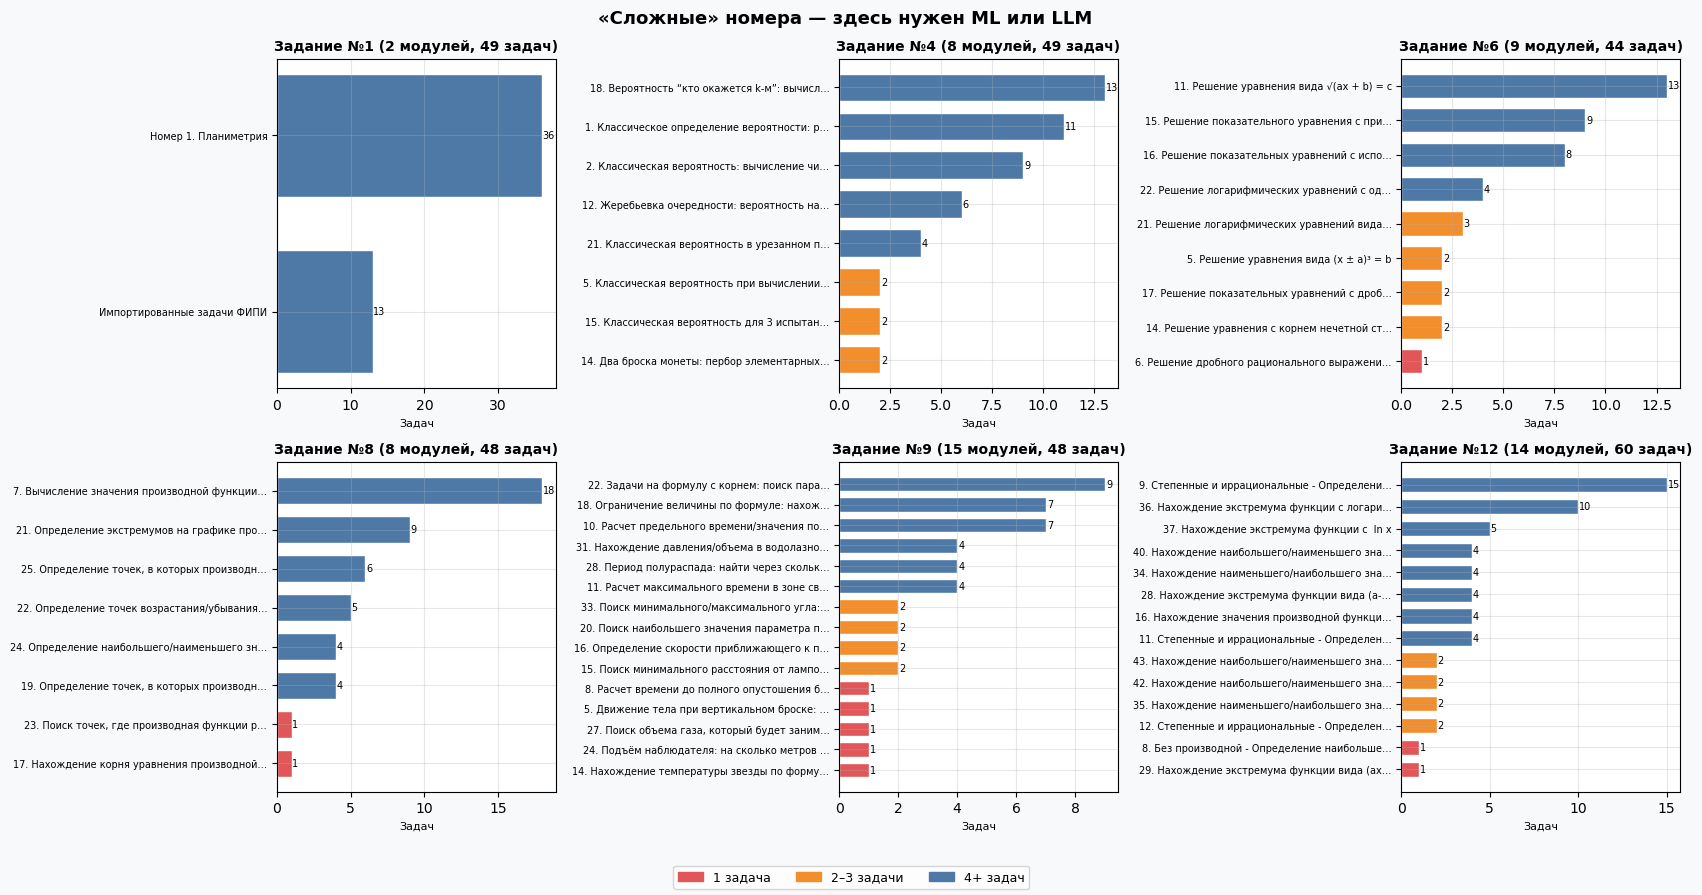

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, num in zip(axes.flat, HARD_NUMS[:6]):
    counts = task_df[task_df['task_number'] == num].groupby('node_name').size().sort_values()
    labels = [n[:42] + ('…' if len(n) > 42 else '') for n in counts.index]
    colors = ['#e15759' if c == 1 else '#f28e2b' if c <= 3 else '#4e79a7' for c in counts]
    bars = ax.barh(range(len(counts)), counts.values, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'Задание №{num} ({len(counts)} модулей, {counts.sum()} задач)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Задач', fontsize=8)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + .05, bar.get_y() + bar.get_height() / 2, str(val), va='center', fontsize=7)

for ax in axes.flat[len(HARD_NUMS[:6]):]:
    ax.axis('off')

patches = [
    mpatches.Patch(color='#e15759', label='1 задача'),
    mpatches.Patch(color='#f28e2b', label='2–3 задачи'),
    mpatches.Patch(color='#4e79a7', label='4+ задач'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9)
plt.suptitle('«Сложные» номера — здесь нужен ML или LLM', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()



## 4. Эмбеддинг: текст → вектор


In [ ]:

TFIDF_PARAMS = dict(ngram_range=(1, 2), min_df=1, max_features=5000, sublinear_tf=True)
N_SVD = 50

texts = task_df['text'].astype(str).tolist()

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_raw = vectorizer.fit_transform(texts)

n_comp = min(N_SVD, X_raw.shape[1] - 1, len(texts) - 1)
svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
X_embed = normalize(svd.fit_transform(X_raw))

print(f"Словарь TF-IDF: {X_raw.shape[1]} токенов")
print(f"После SVD({n_comp}): {X_embed.shape}")
print(f"Объясн. дисперсия: {svd.explained_variance_ratio_.sum():.3f}")

SIM_MATRIX = cosine_similarity(X_embed)
print(f"\nМатрица сходств: {SIM_MATRIX.shape} предвычислена")


Словарь TF-IDF: 5000 токенов
После SVD(50): (528, 50)
Объясн. дисперсия: 0.527

Матрица сходств: (528, 528) предвычислена



## 5. Подход 1: KNN Retrieval

In [ ]:
def knn_predict(query_vec: np.ndarray,
                train_vecs: np.ndarray,
                train_labels: np.ndarray,
                k: int = 5,
                return_candidates: bool = False):
    if len(train_vecs) == 0:
        if return_candidates:
            return '__no_data__', []
        return '__no_data__'

    sims = train_vecs @ query_vec
    top_k = np.argsort(sims)[::-1][:k]

    votes: dict[str, float] = defaultdict(float)
    for idx in top_k:
        votes[str(train_labels[idx])] += float(sims[idx])

    ranked = sorted(votes.items(), key=lambda x: -x[1])
    pred = ranked[0][0]

    if return_candidates:
        candidates = [(label, score, score) for label, score in ranked]
        return pred, candidates
    return pred


class ClusteringPredictor:
    def __init__(self, k: int = 5, filter_num: bool = True):
        self.k = k
        self.filter_num = filter_num
        self._lookup: dict[int, str] = {}
        self._hard_nums: set[int] = set()
        self._train_vecs: dict[int, np.ndarray] = {}
        self._train_labs: dict[int, np.ndarray] = {}
        self._train_meta: dict[int, pd.DataFrame] = {}

    def fit(self, task_df: pd.DataFrame, X_embed: np.ndarray):
        modules_per_num = task_df.groupby('task_number')['node_name'].nunique()

        for num, n_mods in modules_per_num.items():
            num = int(num)
            mask = (task_df['task_number'] == num).values
            if n_mods == 1:
                self._lookup[num] = task_df.loc[mask, 'node_name'].iloc[0]
            else:
                self._hard_nums.add(num)
                self._train_vecs[num] = X_embed[mask]
                self._train_labs[num] = task_df.loc[mask, 'node_name'].values
                meta_cols = [c for c in ['task_id', 'task_name', 'node_name', 'text'] if c in task_df.columns]
                self._train_meta[num] = task_df.loc[mask, meta_cols].copy()
        return self

    def predict(self, task_number: int, text_vec: np.ndarray, return_candidates: bool = False):
        num = int(task_number)
        if num in self._lookup:
            if return_candidates:
                return self._lookup[num], [(self._lookup[num], 1.0, 1.0)]
            return self._lookup[num]

        if num in self._hard_nums:
            return knn_predict(
                text_vec,
                self._train_vecs[num],
                self._train_labs[num],
                k=min(self.k, len(self._train_labs[num])),
                return_candidates=return_candidates,
            )
        return ('__unknown__', []) if return_candidates else '__unknown__'

    def embed_text(self, text: str) -> np.ndarray:
        X = vectorizer.transform([text])
        v = normalize(svd.transform(X))
        return v[0]

print("ClusteringPredictor определён")


✓ ClusteringPredictor определён


In [ ]:

predictor_knn = ClusteringPredictor(k=5, filter_num=True)
predictor_knn.fit(task_df, X_embed)

print("Готово.")
print(f"  Stage 1 (правило): {len(predictor_knn._lookup)} номеров")
print(f"  Stage 2 (KNN):     {len(predictor_knn._hard_nums)} номеров → {sum(len(v) for v in predictor_knn._train_vecs.values())} задач")


Готово.
  Stage 1 (правило): 10 номеров
  Stage 2 (KNN):     6 номеров → 298 задач


### 5.1 Оценка Подхода 1: leave-one-out на сложных номерах

In [ ]:

ml_mask = task_df['task_number'].isin(HARD_NUMS).values
ml_df = task_df[ml_mask].reset_index(drop=True)
X_ml = X_embed[ml_mask]
y_ml = ml_df['node_name'].values

loo_preds = []
loo_true = []

for i in range(len(ml_df)):
    train_mask = np.ones(len(ml_df), dtype=bool)
    train_mask[i] = False
    X_train = X_ml[train_mask]
    y_train = y_ml[train_mask]

    query = X_ml[i]
    num_i = int(ml_df.iloc[i]['task_number'])
    num_mask = ml_df['task_number'].values[train_mask] == num_i

    if num_mask.sum() == 0:
        loo_preds.append('__no_data__')
        loo_true.append(y_ml[i])
        continue

    pred = knn_predict(query, X_train[num_mask], y_train[num_mask], k=min(5, num_mask.sum()))
    loo_preds.append(pred)
    loo_true.append(y_ml[i])

loo_acc = accuracy_score(loo_true, loo_preds)
print(f"LOO Accuracy (ML-часть, {len(ml_df)} задач): {loo_acc:.3f}")

print()
for num in HARD_NUMS:
    mask = ml_df['task_number'].values == num
    if mask.sum() == 0:
        continue
    acc_n = accuracy_score(np.array(loo_true)[mask], np.array(loo_preds)[mask])
    n_modules = ml_df[mask]['node_name'].nunique()
    print(f"  №{num:2d}: acc={acc_n:.3f} ({ml_df[mask].shape[0]} задач, {n_modules} модулей)")


LOO Accuracy (ML-часть, 298 задач): 0.648

  № 1: acc=0.816 (49 задач, 2 модулей)
  № 4: acc=0.776 (49 задач, 8 модулей)
  № 6: acc=0.455 (44 задач, 9 модулей)
  № 8: acc=0.938 (48 задач, 8 модулей)
  № 9: acc=0.688 (48 задач, 15 модулей)
  №12: acc=0.283 (60 задач, 14 модулей)


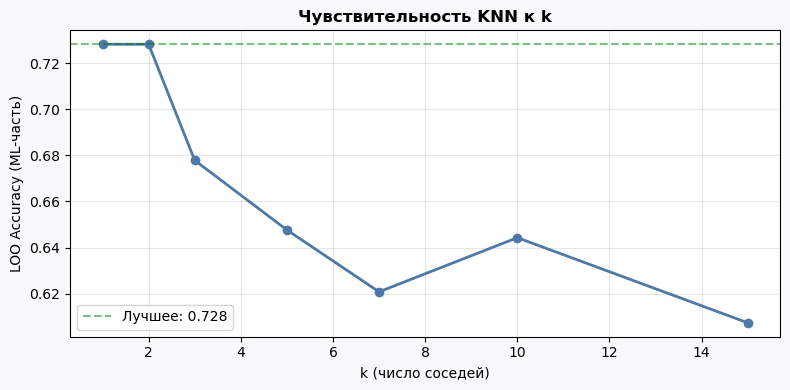

Оптимальное k = 1


In [ ]:
k_range = [1, 2, 3, 5, 7, 10, 15]
k_accs = []

for k in k_range:
    preds_k = []
    for i in range(len(ml_df)):
        train_mask = np.ones(len(ml_df), dtype=bool)
        train_mask[i] = False
        num_i = int(ml_df.iloc[i]['task_number'])
        nm_msk = ml_df['task_number'].values[train_mask] == num_i
        if nm_msk.sum() == 0:
            preds_k.append('')
            continue
        pred = knn_predict(X_ml[i], X_ml[train_mask][nm_msk], y_ml[train_mask][nm_msk], k=min(k, nm_msk.sum()))
        preds_k.append(pred)
    k_accs.append(accuracy_score(loo_true, preds_k))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, k_accs, 'o-', color='#4e79a7', lw=2)
ax.axhline(max(k_accs), color='green', ls='--', alpha=0.5, label=f'Лучшее: {max(k_accs):.3f}')
ax.set_xlabel('k (число соседей)')
ax.set_ylabel('LOO Accuracy (ML-часть)')
ax.set_title('Чувствительность KNN к k', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальное k = {k_range[int(np.argmax(k_accs))]}")


In [ ]:
def show_prediction_1(task_number: int, text: str, true_label: str | None = None):
    num = int(task_number)
    vec = predictor_knn.embed_text(text)
    pred, candidates = predictor_knn.predict(num, vec, return_candidates=True)

    ok = '' if true_label is None else ('✓' if pred == true_label else '✗')
    print(f"{'=' * 70}")
    print(f"  Задание №{num} {ok}")
    print(f"  Текст: {text[:120]}{'…' if len(text) > 120 else ''}")
    if true_label:
        print(f"  Истина:      {true_label}")
    print(f"  Предсказано: {pred}")

    if num in predictor_knn._hard_nums:
        print("\n  Топ кандидатов (взвешенное голосование):")
        max_score = candidates[0][1] if candidates else 1
        for i, (label, score, _) in enumerate(candidates[:6], 1):
            bar = '█' * int(score * 25 / (max_score or 1))
            win = '← победитель' if i == 1 else ''
            print(f"    {i}. {bar:<25} {score:.3f}  {label[:55]} {win}")
    else:
        print("  Stage 1: однозначный номер — правило")
    print()

for num in HARD_NUMS[:6]:
    row = task_df[task_df['task_number'] == num].iloc[0]
    show_prediction_1(row['task_number'], row['text'], true_label=row['node_name'])


  Задание №1 ✓
  Текст: В треугольнике ABC угол C равен 90° , AB=10 , BC= 19 . Найдите cosA .; ;
  Истина:      Номер 1. Планиметрия
  Предсказано: Номер 1. Планиметрия

  Топ кандидатов (взвешенное голосование):
    1. █████████████████████████ 3.977  Номер 1. Планиметрия ← победитель
    2. ████                      0.743  Импортированные задачи ФИПИ 

  Задание №4 ✓
  Текст: Фабрика выпускает сумки. В среднем 4 сумки из 50 имеют скрытый дефект. Найдите вероятность того, что купленная сумка ока…
  Истина:      2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)
  Предсказано: 2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)

  Топ кандидатов (взвешенное голосование):
    1. █████████████████████████ 4.679  2. Классическая вероятность: вычисление числа благоприя ← победитель

  Задание №6 ✓
  Текст: Найдите корень уравнения ( 1 7 ) x 

## 6. Подходы 2 и 3: LLM-only и Hybrid KNN + LLM


In [ ]:
import os
import shutil
import subprocess
import requests

LLM_BACKEND = os.environ.get("LLM_BACKEND", "ollama")  # "ollama" | "openai_compatible"
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434")
OLLAMA_CHAT_URL = OLLAMA_BASE_URL.rstrip("/") + "/api/chat"
OLLAMA_TAGS_URL = OLLAMA_BASE_URL.rstrip("/") + "/api/tags"
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "qwen3:14b")
OLLAMA_NUM_CTX = int(os.environ.get("OLLAMA_NUM_CTX", "4096"))

# OpenAI-compatible settings
OPENAI_COMPATIBLE_BASE_URL = os.environ.get("OPENAI_COMPATIBLE_BASE_URL", "https://openrouter.ai/api/v1")
OPENAI_COMPATIBLE_API_KEY = os.environ.get("OPENAI_COMPATIBLE_API_KEY", "")
OPENAI_COMPATIBLE_MODEL = os.environ.get("OPENAI_COMPATIBLE_MODEL", "")


def _find_ollama_exe():
    """Ищет ollama.exe/ollama для вызова `ollama ps` из Jupyter."""
    found = shutil.which("ollama")
    if found:
        return found

    candidates = []
    localapp = os.environ.get("LOCALAPPDATA")
    if localapp:
        candidates.append(os.path.join(localapp, "Programs", "Ollama", "ollama.exe"))
    candidates += [
        r"C:\Program Files\Ollama\ollama.exe",
        r"C:\Users\alexs\AppData\Local\Programs\Ollama\ollama.exe",
    ]
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


def show_nvidia_smi():
    """Печатает nvidia-smi, если NVIDIA GPU доступна в системе."""
    try:
        out = subprocess.check_output(["nvidia-smi"], stderr=subprocess.STDOUT, text=True)
        print(out)
    except Exception as e:
        print("nvidia-smi недоступен или NVIDIA GPU не найдена.")
        print(f"Детали: {e}")


def show_nvidia_memory():
    """Короткая проверка видеопамяти: имя GPU, total/used/free MB."""
    try:
        cmd = [
            "nvidia-smi",
            "--query-gpu=name,memory.total,memory.used,memory.free,utilization.gpu",
            "--format=csv,noheader,nounits",
        ]
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, text=True).strip()
        print("GPU memory / utilization:")
        print(out)
    except Exception as e:
        print("Не удалось получить краткую статистику nvidia-smi.")
        print(f"Детали: {e}")


def show_ollama_ps():
    """Показывает загруженные в Ollama модели и процессор выполнения."""
    ollama_exe = _find_ollama_exe()
    if not ollama_exe:
        print("ollama ps недоступен: ollama не найдена в PATH и стандартных папках.")
        return
    try:
        out = subprocess.check_output([ollama_exe, "ps"], stderr=subprocess.STDOUT, text=True)
        print(out)
    except Exception as e:
        print("ollama ps недоступен.")
        print(f"Использованный путь: {ollama_exe}")
        print(f"Детали: {e}")


def check_torch_cuda():
    """Дополнительная проверка CUDA внутри Python. Ollama работает отдельным процессом."""
    try:
        import torch
        print("torch version:", torch.__version__)
        print("torch CUDA available:", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("GPU:", torch.cuda.get_device_name(0))
            print("CUDA runtime in PyTorch:", torch.version.cuda)
            print("Capability:", torch.cuda.get_device_capability(0))
            total = torch.cuda.get_device_properties(0).total_memory / 1024**3
            print(f"VRAM total: {total:.1f} GB")
    except Exception as e:
        print("PyTorch не установлен или CUDA внутри Python недоступна.")
        print("Для Ollama это не критично: Ollama использует свой runtime.")
        print(f"Детали: {e}")


print(f"LLM_BACKEND = {LLM_BACKEND}")
print(f"OLLAMA_MODEL = {OLLAMA_MODEL}")
print(f"OLLAMA_CHAT_URL = {OLLAMA_CHAT_URL}")
print(f"OLLAMA_NUM_CTX = {OLLAMA_NUM_CTX}")
if LLM_BACKEND == "openai_compatible":
    print(f"OPENAI_COMPATIBLE_BASE_URL = {OPENAI_COMPATIBLE_BASE_URL}")
    print(f"OPENAI_COMPATIBLE_MODEL = {OPENAI_COMPATIBLE_MODEL or '<not set>'}")
print("\nПроверка NVIDIA GPU через nvidia-smi:")
show_nvidia_memory()
print("\nПроверка CUDA внутри Python, если установлен torch:")
check_torch_cuda()


def call_ollama(prompt: str,
                model: str = None,
                temperature: float = 0.0,
                max_tokens: int = 32,
                num_predict: int = None,
                timeout: int = 180) -> str:
    """
    Вызывает локальную модель Ollama через /api/chat и возвращает message.content.

    Для Qwen3 обязательно ставим think=False: иначе модель может потратить весь лимит
    на поле message.thinking, а message.content будет пустым.
    """
    model = model or OLLAMA_MODEL
    n_tokens = int(num_predict if num_predict is not None else max_tokens)

    payload = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "think": False,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": n_tokens,
            "num_ctx": OLLAMA_NUM_CTX,
        },
    }
    resp = requests.post(OLLAMA_CHAT_URL, json=payload, timeout=timeout)
    resp.raise_for_status()
    data = resp.json()
    return data["message"]["content"].strip()


def test_ollama_gpu(model: str = None):
    """
    Практическая проверка, что Ollama реально загружает модель на GPU.

    Как читать результат:
    1. Если после вызова в `ollama ps` в колонке PROCESSOR указано `100% GPU` или близко к этому — модель на GPU.
    2. Если в `nvidia-smi` выросла used VRAM и виден процесс ollama.exe — GPU используется.
    3. Если PROCESSOR = CPU или VRAM почти не меняется — модель ушла на CPU.
    """
    import time
    model = model or OLLAMA_MODEL
    print(f"Testing Ollama model: {model}")
    print("\nBefore generation:")
    show_nvidia_memory()
    print("\nOllama loaded models before:")
    show_ollama_ps()

    t0 = time.time()
    try:
        ans = call_ollama(
            "Return exactly one word: OK",
            model=model,
            temperature=0.0,
            max_tokens=16,
            timeout=240,
        )
        dt = time.time() - t0
        print(f"\nResponse: {ans!r}")
        print(f"Generation time: {dt:.2f} sec")
    except Exception as e:
        print("\nOllama generation failed.")
        print("Проверь: 1) запущена ли Ollama, 2) скачана ли модель, 3) хватает ли VRAM.")
        print(f"Детали: {e}")
        return

    print("\nAfter generation:")
    show_nvidia_memory()
    print("\nOllama loaded models after:")
    show_ollama_ps()


def call_openai_compatible(system_prompt: str,
                           user_message: str,
                           max_tokens: int = 32,
                           temperature: float = 0.0,
                           timeout: int = 60) -> str:
    """
    Вызывает OpenAI-compatible Chat Completions API.

    Подходит для:
      - OpenRouter
      - Together
      - Groq
      - LM Studio
      - vLLM
    """
    if not OPENAI_COMPATIBLE_MODEL:
        raise ValueError("OPENAI_COMPATIBLE_MODEL не задан.")

    url = OPENAI_COMPATIBLE_BASE_URL.rstrip("/") + "/chat/completions"
    headers = {"Content-Type": "application/json"}
    if OPENAI_COMPATIBLE_API_KEY:
        headers["Authorization"] = f"Bearer {OPENAI_COMPATIBLE_API_KEY}"

    payload = {
        "model": OPENAI_COMPATIBLE_MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
        ],
        "temperature": temperature,
        "max_tokens": max_tokens,
    }
    resp = requests.post(url, headers=headers, json=payload, timeout=timeout)
    resp.raise_for_status()
    data = resp.json()
    return data["choices"][0]["message"]["content"].strip()


print("\nДля практической проверки GPU запусти следующую строку в отдельной ячейке:")
print("test_ollama_gpu()")
print("\nДля быстрой проверки ответа модели:")
print('print(call_ollama("Return exactly one word: OK", model=OLLAMA_MODEL, max_tokens=16))')


LLM_BACKEND = ollama
OLLAMA_MODEL = qwen3:14b
OLLAMA_CHAT_URL = http://localhost:11434/api/chat
OLLAMA_NUM_CTX = 4096

Проверка NVIDIA GPU через nvidia-smi:
GPU memory / utilization:
NVIDIA GeForce RTX 5070 Ti, 16303, 11959, 4039, 0

Проверка CUDA внутри Python, если установлен torch:
PyTorch не установлен или CUDA внутри Python недоступна.
Для Ollama это не критично: Ollama использует свой runtime.
Детали: No module named 'torch'

Для практической проверки GPU запусти следующую строку в отдельной ячейке:
test_ollama_gpu()

Для быстрой проверки ответа модели:
print(call_ollama("Return exactly one word: OK", model=OLLAMA_MODEL, max_tokens=16))


In [ ]:

SYSTEM_PROMPT = """Ты — опытный учитель математики.
Твоя задача: определить, к какому учебному микромодулю относится задача ЕГЭ.
Микромодуль — это конкретная подтема внутри одного задания ЕГЭ.

Правила ответа:
- Отвечай ТОЛЬКО номером из предложенного списка, например: 3
- Никакого дополнительного текста, только цифра
- Если уверен меньше чем на 70%, выбери ближайший по смыслу"""


def build_prompt(task_number: int, condition: str, candidates: list[str]) -> str:
    """Строит prompt для LLM с условием задачи и списком кандидатов."""
    candidates_str = "\n".join(f"{i + 1}. {c}" for i, c in enumerate(candidates))
    return (
        f"Задание ЕГЭ №{task_number}\n\n"
        f"Условие задачи:\n{condition[:600]}\n\n"
        f"Выбери подходящий микромодуль из списка:\n{candidates_str}\n\n"
        f"Ответ (только номер из списка):"
    )


def parse_llm_choice(response: str, candidates: list[str]) -> str:
    nums = re.findall(r'\b(\d+)\b', response)
    if nums:
        idx = int(nums[0]) - 1
        if 0 <= idx < len(candidates):
            return candidates[idx]

    resp_lower = response.lower()
    for c in candidates:
        if c.lower()[:20] in resp_lower:
            return c
    return candidates[0]

example_candidates = [
    'Классическое определение вероятности',
    'Вычисление через дополнение',
    'Задачи с монетами',
    'Урезанное пространство исходов',
    'Комбинаторный подход',
]

if 4 in set(task_df['task_number']):
    example = task_df[task_df['task_number'] == 4].iloc[0]
    print(build_prompt(4, example['text'], example_candidates))


Задание ЕГЭ №4

Условие задачи:
Фабрика выпускает сумки. В среднем 4 сумки из 50 имеют скрытый дефект. Найдите вероятность того, что купленная сумка окажется без скрытого дефекта.; ;

Выбери подходящий микромодуль из списка:
1. Классическое определение вероятности
2. Вычисление через дополнение
3. Задачи с монетами
4. Урезанное пространство исходов
5. Комбинаторный подход

Ответ (только номер из списка):


In [ ]:
def get_modules_for_task_number(task_number: int) -> list[str]:
    return (
        task_df[task_df["task_number"] == int(task_number)]["node_name"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )


def llm_choose_from_candidates(task_number: int,
                               condition: str,
                               candidates: list[str],
                               verbose: bool = False) -> dict:
    if not candidates:
        return {
            "prediction": "__no_candidates__",
            "choice": None,
            "raw_response": "",
            "fallback": True,
        }

    user_prompt = build_prompt(task_number, condition, candidates)

    try:
        if LLM_BACKEND == "ollama":
            full_prompt = f"{SYSTEM_PROMPT}\n\n{user_prompt}"
            raw_response = call_ollama(
                prompt=full_prompt,
                model=OLLAMA_MODEL,
                max_tokens=16,
                temperature=0.0,
            )
        elif LLM_BACKEND == "openai_compatible":
            raw_response = call_openai_compatible(
                system_prompt=SYSTEM_PROMPT,
                user_message=user_prompt,
                max_tokens=16,
                temperature=0.0,
            )
        else:
            raise ValueError(f"Неизвестный LLM_BACKEND: {LLM_BACKEND}")

        prediction = parse_llm_choice(raw_response, candidates)
        choice = candidates.index(prediction) + 1 if prediction in candidates else None
        result = {
            "prediction": prediction,
            "choice": choice,
            "raw_response": raw_response,
            "fallback": False,
            "backend": LLM_BACKEND,
            "model": OLLAMA_MODEL if LLM_BACKEND == "ollama" else OPENAI_COMPATIBLE_MODEL,
        }
    except Exception as e:
        result = {
            "prediction": candidates[0],
            "choice": 1,
            "raw_response": str(e),
            "fallback": True,
        }

    if verbose:
        print("Кандидаты:")
        for i, c in enumerate(candidates, 1):
            print(f"  {i}. {c}")
        print(f"LLM raw: {result['raw_response']}")
        print(f"Выбор: {result['prediction']}")
        if result.get("fallback"):
            print("Использован fallback: LLM недоступна или ответ не распарсился.")

    return result


class LLMOnlyPredictor:
    def predict(self, task_number: int, text: str, verbose: bool = False) -> dict:
        candidates = get_modules_for_task_number(task_number)

        if len(candidates) == 1:
            return {
                "prediction": candidates[0],
                "method": "rule",
                "candidates": candidates,
                "llm_response": "",
            }

        result = llm_choose_from_candidates(task_number, text, candidates, verbose=verbose)

        return {
            "prediction": result["prediction"],
            "method": "llm_only_fallback" if result.get("fallback") else "llm_only",
            "candidates": candidates,
            "llm_response": result["raw_response"],
            "choice": result["choice"],
        }


class HybridPredictor:
    def __init__(self, k_candidates: int = 6, k_knn: int = 7, use_llm: bool = True):
        self.k_candidates = k_candidates
        self.k_knn = k_knn
        self.use_llm = use_llm
        self._lookup: dict[int, str] = {}
        self._hard_nums: set[int] = set()
        self._train_vecs: dict[int, np.ndarray] = {}
        self._train_labs: dict[int, np.ndarray] = {}

    def fit(self, task_df: pd.DataFrame, X_embed: np.ndarray):
        modules_per_num = task_df.groupby("task_number")["node_name"].nunique()
        for num, n_mods in modules_per_num.items():
            num = int(num)
            mask = (task_df["task_number"] == num).values
            if n_mods == 1:
                self._lookup[num] = task_df.loc[mask, "node_name"].iloc[0]
            else:
                self._hard_nums.add(num)
                self._train_vecs[num] = X_embed[mask]
                self._train_labs[num] = task_df.loc[mask, "node_name"].values
        return self

    def embed_text(self, text: str) -> np.ndarray:
        X = vectorizer.transform([text])
        return normalize(svd.transform(X))[0]

    def get_candidates(self, task_number: int, text_vec: np.ndarray) -> list[str]:
        num = int(task_number)

        if num not in self._hard_nums:
            return [self._lookup.get(num, "__unknown__")]

        _, ranked = knn_predict(
            text_vec,
            self._train_vecs[num],
            self._train_labs[num],
            k=min(self.k_knn, len(self._train_labs[num])),
            return_candidates=True,
        )

        seen, unique = set(), []
        for label, score, _ in ranked:
            if label not in seen:
                seen.add(label)
                unique.append(label)
            if len(unique) >= self.k_candidates:
                break

        return unique

    def predict(self, task_number: int, text: str, verbose: bool = False) -> dict:
        num = int(task_number)
        vec = self.embed_text(text)

        if num in self._lookup:
            return {
                "prediction": self._lookup[num],
                "method": "rule",
                "candidates": [],
                "llm_response": "",
            }

        candidates = self.get_candidates(num, vec)

        if not self.use_llm or len(candidates) == 1:
            return {
                "prediction": candidates[0],
                "method": "knn",
                "candidates": candidates,
                "llm_response": "",
            }

        result = llm_choose_from_candidates(num, text, candidates, verbose=verbose)

        return {
            "prediction": result["prediction"],
            "method": "hybrid_fallback" if result.get("fallback") else "hybrid",
            "candidates": candidates,
            "llm_response": result["raw_response"],
            "choice": result["choice"],
        }


llm_only_predictor = LLMOnlyPredictor()

hybrid_predictor = HybridPredictor(k_candidates=6, k_knn=7, use_llm=True)
hybrid_predictor.fit(task_df, X_embed)

print("LLMOnlyPredictor готов")
print("HybridPredictor готов")


✓ LLMOnlyPredictor готов
✓ HybridPredictor готов


In [ ]:
def show_prediction_3(task_number: int, text: str, true_label: str | None = None):
    print(f"{'=' * 70}")
    print(f"Задание №{task_number}")
    print(f"Текст: {text[:180]}{'…' if len(text) > 180 else ''}")
    if true_label:
        print(f"Истина: {true_label}")
    print()

    result = hybrid_predictor.predict(task_number, text, verbose=True)
    pred = result['prediction']
    ok = '' if true_label is None else ('✓' if pred == true_label else '✗')

    print(f"Метод: {result['method']}")
    print(f"Предсказано {ok}: {pred}")
    print()

for num in [n for n in [4, 6, 9] if n in set(task_df['task_number'])]:
    row = task_df[task_df['task_number'] == num].iloc[0]
    show_prediction_3(row['task_number'], row['text'], row['node_name'])


Задание №4
Текст: Фабрика выпускает сумки. В среднем 4 сумки из 50 имеют скрытый дефект. Найдите вероятность того, что купленная сумка окажется без скрытого дефекта.; ;
Истина: 2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)

Кандидаты:
  1. 2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)
  2. 14. Два броска монеты: пербор элементарных исходов и отбор благоприятных
LLM raw: 1
Выбор: 2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)
Метод: hybrid
Предсказано ✓: 2. Классическая вероятность: вычисление числа благоприятных исходов через дополнение и суммирование (с округлением результата)

Задание №6
Текст: Найдите корень уравнения ( 1 7 ) x + 4 =49 .; ;
Истина: 16. Решение показательных уравнений с использованием отрицательных степеней

Кандидаты:
  1. 16. Р

## 7. Сравнение трёх подходов: KNN-only, Qwen-only, Hybrid KNN + Qwen

В этом разделе сравниваются все три требуемых варианта:

1. **Подход 1 — KNN-only**: классификация только через поиск похожих размеченных задач.
2. **Подход 2 — Qwen-only**: локальная Qwen3 выбирает микромодуль из всех допустимых микромодулей для данного номера ЕГЭ.
3. **Подход 3 — Hybrid KNN + Qwen**: KNN сначала сужает список кандидатов, затем Qwen выбирает финальный микромодуль.

Важно: здесь не используется внешний LLM API. Все LLM-вызовы идут в локальную модель Qwen через Ollama.


In [ ]:
import os

LLM_BACKEND = "ollama"
OLLAMA_MODEL = "qwen3:14b"

os.environ["LLM_BACKEND"] = LLM_BACKEND
os.environ["OLLAMA_MODEL"] = OLLAMA_MODEL

print("LLM_BACKEND:", LLM_BACKEND)
print("OLLAMA_MODEL:", OLLAMA_MODEL)
print("Ollama URL:", OLLAMA_CHAT_URL)


LLM_BACKEND: ollama
OLLAMA_MODEL: qwen3:14b
Ollama URL: http://localhost:11434/api/chat


In [ ]:
try:
    qwen_test = call_ollama(
        "Return exactly one number: 1",
        model=OLLAMA_MODEL,
        num_predict=8,
        temperature=0.0,
    )

    QWEN_AVAILABLE = bool(str(qwen_test).strip())

    print("Qwen test response:", repr(qwen_test))
    print("QWEN_AVAILABLE:", QWEN_AVAILABLE)

    if not QWEN_AVAILABLE:
        raise RuntimeError(
            "Qwen вернул пустой ответ. Проверь, что call_ollama использует /api/chat и think=False."
        )

except Exception as e:
    QWEN_AVAILABLE = False
    print("QWEN_AVAILABLE:", QWEN_AVAILABLE)
    print("Qwen error:", repr(e))
    raise


Qwen test response: '1'
QWEN_AVAILABLE: True


In [ ]:
def predict_qwen_only(task_number: int, condition: str, verbose: bool = False) -> dict:
    result = llm_only_predictor.predict(
        task_number=int(task_number),
        text=condition,
        verbose=verbose,
    )

    if result.get("method") == "llm_only":
        result["method"] = "qwen_only"
    elif result.get("method") == "llm_only_fallback":
        result["method"] = "qwen_only_fallback"

    return result

example_row = task_df[task_df["task_number"].isin(HARD_NUMS)].iloc[0]
example_res = predict_qwen_only(
    task_number=example_row["task_number"],
    condition=example_row["text"],
    verbose=False,
)

print("Qwen-only sanity check:")
print("  task_number:", int(example_row["task_number"]))
print("  true:", example_row["node_name"])
print("  pred:", example_res["prediction"])
print("  method:", example_res["method"])
print("  raw:", repr(example_res.get("llm_response", "")))


Qwen-only sanity check:
  task_number: 6
  true: 16. Решение показательных уравнений с использованием отрицательных степеней
  pred: 15. Решение показательного уравнения с приведением к одному основанию
  method: qwen_only
  raw: '2'


In [ ]:
if not QWEN_AVAILABLE:
    raise RuntimeError("Qwen недоступен. Сначала запусти проверку QWEN_AVAILABLE выше.")

SAMPLE = min(25, len(ml_df))

sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(ml_df),
    SAMPLE,
    replace=False
)

results_comparison = []

print(f"Оцениваем {SAMPLE} задач из ML-части...")
print("Подходы: KNN-only | Qwen-only | Hybrid KNN+Qwen")
print()

for step, i in enumerate(sample_idx, 1):
    row = ml_df.iloc[i]

    num = int(row["task_number"])
    text = str(row["text"])
    true = str(row["node_name"])
    vec_i = X_ml[i]

    mask_i = np.ones(len(ml_df), dtype=bool)
    mask_i[i] = False

    num_mask_i = ml_df["task_number"].values[mask_i] == num

    if num_mask_i.sum() == 0:
        pred_knn = "__no_data__"
    else:
        pred_knn = knn_predict(
            vec_i,
            X_ml[mask_i][num_mask_i],
            y_ml[mask_i][num_mask_i],
            k=min(5, num_mask_i.sum())
        )
    res_qwen = predict_qwen_only(
        task_number=num,
        condition=text,
        verbose=False
    )

    pred_qwen = str(res_qwen["prediction"])
    method_qwen = res_qwen["method"]
    res_hybrid = hybrid_predictor.predict(
        task_number=num,
        text=text,
        verbose=False
    )

    pred_hybrid = str(res_hybrid["prediction"])
    method_hybrid = res_hybrid["method"]

    results_comparison.append({
        "task_number": num,
        "true": true,

        "pred_knn": pred_knn,
        "pred_qwen": pred_qwen,
        "pred_hybrid": pred_hybrid,

        "method_qwen": method_qwen,
        "method_hybrid": method_hybrid,

        "knn_correct": pred_knn == true,
        "qwen_correct": pred_qwen == true,
        "hybrid_correct": pred_hybrid == true,

        "qwen_candidates_count": len(res_qwen.get("candidates", [])),
        "hybrid_candidates_count": len(res_hybrid.get("candidates", [])),
        "hybrid_candidates": res_hybrid.get("candidates", []),
        "qwen_raw": res_qwen.get("llm_response", ""),
        "hybrid_raw": res_hybrid.get("llm_response", ""),
    })

    status = (
        f"knn={'✓' if pred_knn == true else '✗'} | "
        f"qwen={'✓' if pred_qwen == true else '✗'} | "
        f"hybrid={'✓' if pred_hybrid == true else '✗'}"
    )

    print(f"{step:02d}/{SAMPLE}  №{num:2d} {status}  [{true[:55]}]")

df_cmp = pd.DataFrame(results_comparison)

print()
print("=" * 70)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 70)
print(f"Подход 1 — KNN-only:          {df_cmp['knn_correct'].mean():.3f}")
print(f"Подход 2 — Qwen-only:         {df_cmp['qwen_correct'].mean():.3f}")
print(f"Подход 3 — Hybrid KNN+Qwen:   {df_cmp['hybrid_correct'].mean():.3f}")

df_cmp.head()


Оцениваем 25 задач из ML-части...
Подходы: KNN-only | Qwen-only | Hybrid KNN+Qwen

01/25  №12 knn=✗ | qwen=✓ | hybrid=✓  [9. Степенные и иррациональные - Определение  экстремумо]
02/25  № 6 knn=✓ | qwen=✗ | hybrid=✓  [11. Решение уравнения вида √(ax + b) = c]
03/25  № 1 knn=✗ | qwen=✗ | hybrid=✗  [Импортированные задачи ФИПИ]
04/25  №12 knn=✓ | qwen=✗ | hybrid=✓  [36. Нахождение экстремума функции с логарифмом и ограни]
05/25  № 8 knn=✓ | qwen=✓ | hybrid=✓  [24. Определение наибольшего/наименьшего значения произв]
06/25  № 4 knn=✓ | qwen=✓ | hybrid=✓  [21. Классическая вероятность в урезанном пространстве и]
07/25  № 8 knn=✓ | qwen=✓ | hybrid=✓  [25. Определение точек, в которых производная функции от]
08/25  №12 knn=✗ | qwen=✗ | hybrid=✗  [11. Степенные и иррациональные - Определение точки экст]
09/25  №12 knn=✗ | qwen=✓ | hybrid=✓  [12. Степенные и иррациональные - Определение экстремума]
10/25  № 4 knn=✓ | qwen=✓ | hybrid=✓  [12. Жеребьевка очередности: вероятность на "фиксированн]


,task_number,true,pred_knn,pred_qwen,pred_hybrid,method_qwen,method_hybrid,knn_correct,qwen_correct,hybrid_correct,qwen_candidates_count,hybrid_candidates_count,hybrid_candidates,qwen_raw,hybrid_raw
0,12,9. Степенные и иррациональные - Определение экстремумов кубической функции через анал...,28. Нахождение экстремума функции вида (а-х)*е^(в-х),9. Степенные и иррациональные - Определение экстремумов кубической функции через анал...,9. Степенные и иррациональные - Определение экстремумов кубической функции через анал...,qwen_only,hybrid,False,True,True,14,4,[9. Степенные и иррациональные - Определение экстремумов кубической функции через ана...,4,1
1,6,11. Решение уравнения вида √(ax + b) = c,11. Решение уравнения вида √(ax + b) = c,6. Решение дробного рационального выражения,11. Решение уравнения вида √(ax + b) = c,qwen_only,hybrid,True,False,True,9,3,"[11. Решение уравнения вида √(ax + b) = c, 16. Решение показательных уравнений с испол...",9,1
2,1,Импортированные задачи ФИПИ,Номер 1. Планиметрия,Номер 1. Планиметрия,Номер 1. Планиметрия,qwen_only,hybrid,False,False,False,2,2,"[Номер 1. Планиметрия, Импортированные задачи ФИПИ]",1,1
3,12,36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ,36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ,37. Нахождение экстремума функции с ln x,36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ,qwen_only,hybrid,True,False,True,14,3,"[36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ, 11. Степенные и...",1,1
4,8,24. Определение наибольшего/наименьшего значения производной функции,24. Определение наибольшего/наименьшего значения производной функции,24. Определение наибольшего/наименьшего значения производной функции,24. Определение наибольшего/наименьшего значения производной функции,qwen_only,hybrid,True,True,True,8,2,"[24. Определение наибольшего/наименьшего значения производной функции, 22. Определение...",6,1


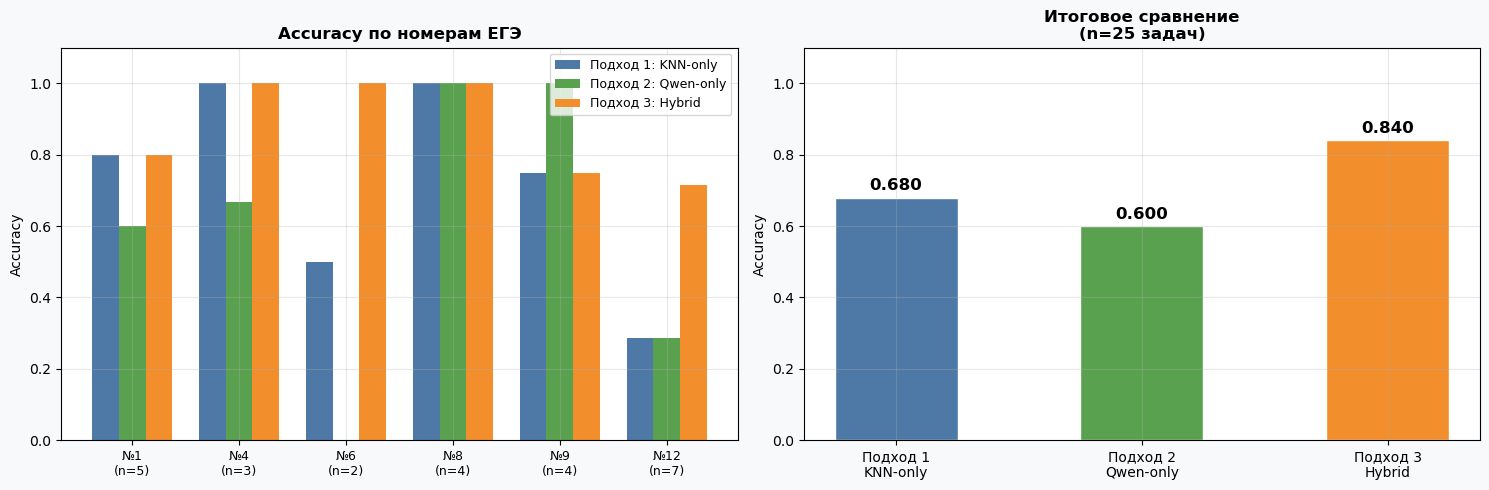

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

num_acc = df_cmp.groupby("task_number").agg(
    knn=("knn_correct", "mean"),
    qwen=("qwen_correct", "mean"),
    hybrid=("hybrid_correct", "mean"),
    n=("true", "count")
).reset_index()

x = np.arange(len(num_acc))
w = 0.25

ax = axes[0]

ax.bar(x - w, num_acc["knn"], w, label="Подход 1: KNN-only", color="#4e79a7")
ax.bar(x, num_acc["qwen"], w, label="Подход 2: Qwen-only", color="#59a14f")
ax.bar(x + w, num_acc["hybrid"], w, label="Подход 3: Hybrid", color="#f28e2b")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"№{n}\n(n={r})" for n, r in zip(num_acc["task_number"], num_acc["n"])],
    fontsize=9
)

ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy по номерам ЕГЭ", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

ax2 = axes[1]

methods = [
    "Подход 1\nKNN-only",
    "Подход 2\nQwen-only",
    "Подход 3\nHybrid"
]

accs = [
    df_cmp["knn_correct"].mean(),
    df_cmp["qwen_correct"].mean(),
    df_cmp["hybrid_correct"].mean()
]

colors = ["#4e79a7", "#59a14f", "#f28e2b"]

bars = ax2.bar(methods, accs, color=colors, width=0.5, edgecolor="white")

ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Accuracy")
ax2.set_title(f"Итоговое сравнение\n(n={SAMPLE} задач)", fontsize=12, fontweight="bold")

for bar, acc in zip(bars, accs):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{acc:.3f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
disagree = df_cmp[
    (df_cmp["pred_knn"] != df_cmp["pred_qwen"]) |
    (df_cmp["pred_knn"] != df_cmp["pred_hybrid"]) |
    (df_cmp["pred_qwen"] != df_cmp["pred_hybrid"])
]

print(f"Случаев расхождения между подходами: {len(disagree)} / {len(df_cmp)}")
print()

for _, row in disagree.iterrows():
    knn_ok = "✓" if row["knn_correct"] else "✗"
    qwen_ok = "✓" if row["qwen_correct"] else "✗"
    hyb_ok = "✓" if row["hybrid_correct"] else "✗"

    print(f"№{int(row['task_number'])}")
    print(f"  Истина:       {row['true'][:80]}")
    print(f"  KNN {knn_ok}:        {row['pred_knn'][:80]}")
    print(f"  Qwen {qwen_ok}:       {row['pred_qwen'][:80]}")
    print(f"  Hybrid {hyb_ok}:     {row['pred_hybrid'][:80]}")
    print(f"  Qwen raw:     {repr(row['qwen_raw'])}")
    print(f"  Hybrid raw:   {repr(row['hybrid_raw'])}")
    print()

Случаев расхождения между подходами: 12 / 25

№12
  Истина:       9. Степенные и иррациональные - Определение  экстремумов кубической функции чере
  KNN ✗:        28. Нахождение экстремума функции вида (а-х)*е^(в-х)
  Qwen ✓:       9. Степенные и иррациональные - Определение  экстремумов кубической функции чере
  Hybrid ✓:     9. Степенные и иррациональные - Определение  экстремумов кубической функции чере
  Qwen raw:     '4'
  Hybrid raw:   '1'

№6
  Истина:       11. Решение уравнения вида √(ax + b) = c
  KNN ✓:        11. Решение уравнения вида √(ax + b) = c
  Qwen ✗:       6. Решение дробного рационального выражения
  Hybrid ✓:     11. Решение уравнения вида √(ax + b) = c
  Qwen raw:     '9'
  Hybrid raw:   '1'

№12
  Истина:       36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ
  KNN ✓:        36. Нахождение экстремума функции с логарифмом и ограничением по ОДЗ
  Qwen ✗:       37. Нахождение экстремума функции с  ln x
  Hybrid ✓:     36. Нахождение экстремума 